<a href="https://colab.research.google.com/github/melia1702/pertemuan-kesebelas/blob/main/Tugas_MG_11_Analisis_Bentuk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving WhatsApp Image 2026-04-23 at 21.03.41.jpeg to WhatsApp Image 2026-04-23 at 21.03.41 (3).jpeg
Total gambar: 1


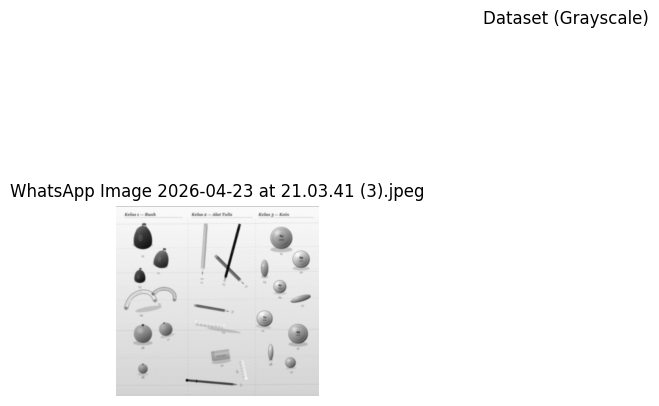

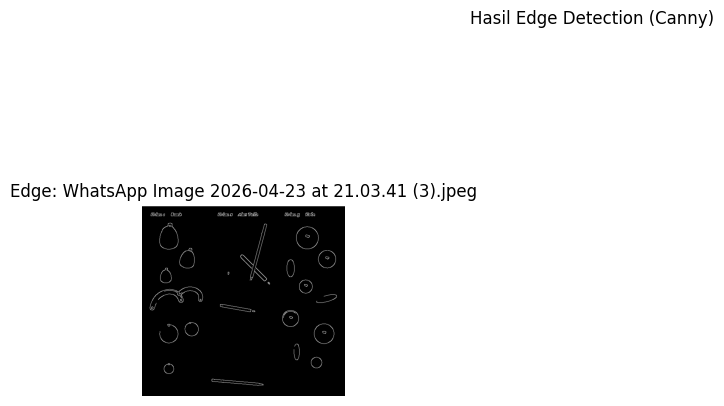

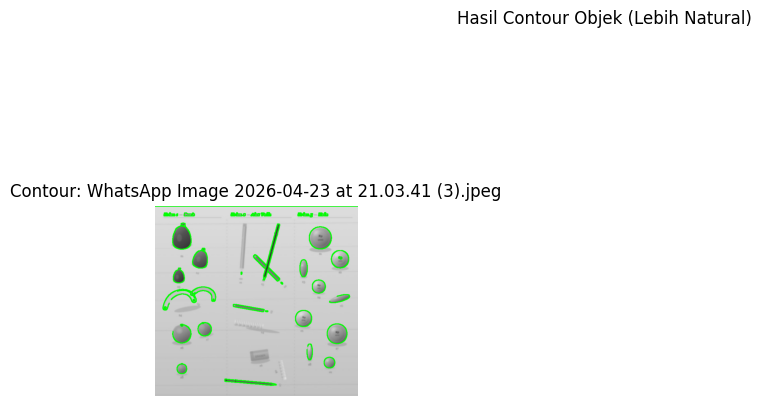

In [18]:
# =========================
# 1. UPLOAD GAMBAR MANUAL
# =========================
from google.colab import files
uploaded = files.upload()

# =========================
# 2. IMPORT LIBRARY
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt

images = []
edges_list = []
names = []

# =========================
# 3. LOAD & PREPROCESS (VERSI BARU)
# =========================
for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        print("Gagal load:", filename)
        continue

    # grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # blur biar halus
    gray = cv2.GaussianBlur(gray, (5,5), 0)

    # EDGE DETECTION (lebih bagus dari threshold)
    edges = cv2.Canny(gray, 100, 200)

    images.append(gray)
    edges_list.append(edges)
    names.append(filename)

print("Total gambar:", len(images))

# =========================
# 4. VISUALISASI DATASET (GRAY)
# =========================
cols = 4
rows = int(np.ceil(len(images)/cols))

plt.figure(figsize=(12,6))

for i in range(len(images)):
    plt.subplot(rows, cols, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(names[i])
    plt.axis('off')

plt.suptitle("Dataset (Grayscale)")
plt.show()

# =========================
# 5. VISUALISASI EDGE (HASIL BAGUS)
# =========================
plt.figure(figsize=(12,6))

for i in range(len(edges_list)):
    plt.subplot(rows, cols, i+1)
    plt.imshow(edges_list[i], cmap='gray')
    plt.title(f"Edge: {names[i]}")
    plt.axis('off')

plt.suptitle("Hasil Edge Detection (Canny)")
plt.show()

# =========================
# 6. VISUALISASI CONTOUR
# =========================
plt.figure(figsize=(12,6))

for i in range(len(edges_list)):
    edge = edges_list[i]

    contours, _ = cv2.findContours(edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = cv2.cvtColor(images[i], cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

    plt.subplot(rows, cols, i+1)
    plt.imshow(contour_img)
    plt.title(f"Contour: {names[i]}")
    plt.axis('off')

plt.suptitle("Hasil Contour Objek (Lebih Natural)")
plt.show()